# **Edward Moswane Final Project**

# Final Project: Customer Churn Prediction Using Machine Learning

## Introduction

Customer churn dataset is selected for this assignment project because it is a relevant important problem for telecommunications companies. Loosing customers can result in reduction of revenue and increase the cost of acquiring new customers. This assignment project develops a machine learning classification model that predicts whether a customer is likely to churn based on demographic, service, and account information.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
    f1_score,roc_auc_score,confusion_matrix,classification_report,roc_curve)

print("Libraries imported successfully.")

Libraries imported successfully.


# Data Preprocessing and Exploration

Load the dataset

In [2]:
# Loading the dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df

Dataset loaded successfully.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Exploring Dataset

In [4]:
# Showing summary information about the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

df.info()

Number of rows: 7043
Number of columns: 21

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   ob

In [5]:
# Descriptive statistics

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Checking for missing or null values

missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values[missing_values > 0])

Missing values by column:
Series([], dtype: int64)


In [7]:
# Converting TotalCharges to numeric blank values will become NaN

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges values:", df["TotalCharges"].isnull().sum())

Missing TotalCharges values: 11


In [8]:
# Removing rows with missing TotalCharges

df = df.dropna(subset=["TotalCharges"])

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [9]:
# Removing customer ID because it is only an identifier

df = df.drop("customerID", axis=1)

print("Customer ID removed.")
print("New shape:", df.shape)

Customer ID removed.
New shape: (7032, 20)


Checking Missing Values

In [10]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Explore the target variable

In [11]:
# Show churn distribution

print(df["Churn"].value_counts())

print("\nChurn_Percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn_Percentages:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


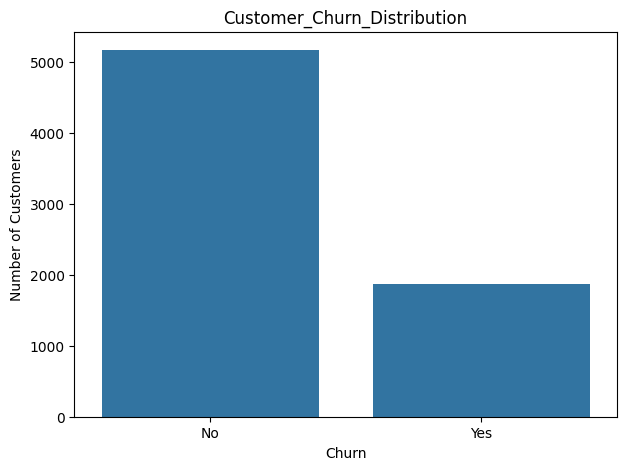

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer_Churn_Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Churn Distribution

The target variable is Churn indicates whether a customer left the telecommunications company. Analizing the distribution of the target variable helps determine whether the dataset is balanced or whether one class occurs more frequently than the other.

Exploring important relationships
Contract type versus churn

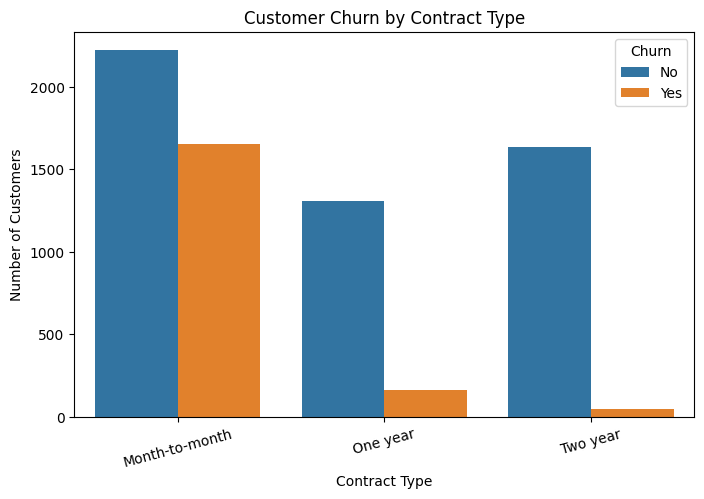

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.show()

Plot of Monthly Charges versus Churn

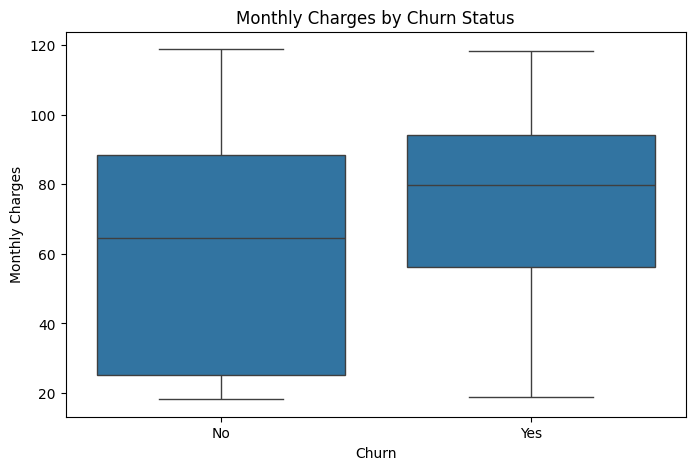

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

Plot of Tenure versus churn

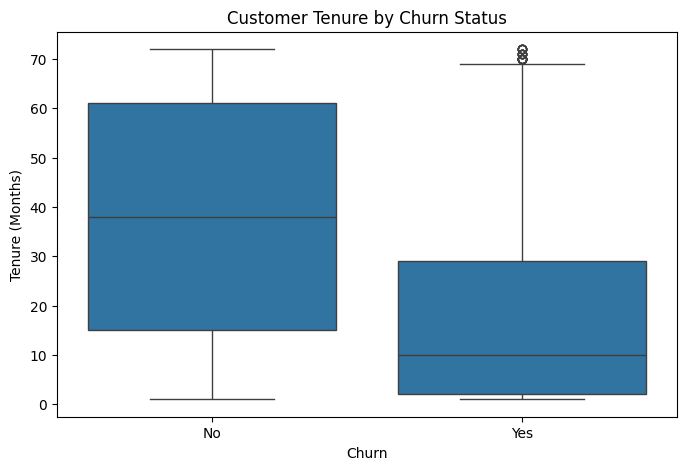

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

Prepare the data for machine learning

In [16]:
# Converting target variable to numerical values

df["Churn"] = df["Churn"].map({"Yes": 1,"No": 0})

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [17]:
# Separating features and target

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


Identify numerical and categorical features

In [18]:
# Identifying numerical and categorical columns

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Preprocessing pipeline

In [19]:
# Preprocessing for numerical features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", __import__("sklearn").preprocessing.OneHotEncoder(handle_unknown="ignore"))])

# Combining preprocessing steps
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)])

print("Preprocessing pipeline has been created successfully!!!!.")

Preprocessing pipeline has been created successfully!!!!.


Train and test split dataset

In [20]:
# Spliting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5625
Testing samples: 1407


Creating Logistic Regression model

In [21]:
# Logistic Regression pipeline
logistic_model = Pipeline(steps=[("preprocessor", preprocessor),("classifier", LogisticRegression(max_iter=1000))])

# Training the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression Model has been Trained Successfully!!!.")

Logistic Regression Model has been Trained Successfully!!!.


In [22]:
# Making Predictions
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

# Calculate metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_auc = roc_auc_score(y_test, y_prob_logistic)

print("___________Logistic Regression Results________________")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))
print("ROC-AUC  :", round(logistic_auc, 4))

___________Logistic Regression Results________________
Accuracy : 0.8038
Precision: 0.6485
Recall   : 0.5722
F1 Score : 0.608
ROC-AUC  : 0.8359


Random Forest Model

In [23]:
# Creating Random Forest pipeline
rf_model = Pipeline(steps=[("preprocessor", preprocessor),("classifier", RandomForestClassifier(random_state=42,n_estimators=200))])

# Training Random Forest
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!!!!.")

Random Forest Model Trained Successfully!!!!.


In [24]:
# Random Forest Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("_Random Forest Results_")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

_Random Forest Results_
Accuracy : 0.7896
Precision: 0.6345
Recall   : 0.492
F1 Score : 0.5542
ROC-AUC  : 0.814


Comparing the models

In [25]:
# Compare model performance
results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest"],
    "Accuracy": [logistic_accuracy,rf_accuracy],
    "Precision": [logistic_precision,rf_precision],
    "Recall": [logistic_recall,rf_recall],
    "F1 Score": [logistic_f1,rf_f1],
    "ROC-AUC": [logistic_auc,rf_auc]})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929
1,Random Forest,0.789623,0.634483,0.491979,0.554217,0.813999


<Figure size 1000x600 with 0 Axes>

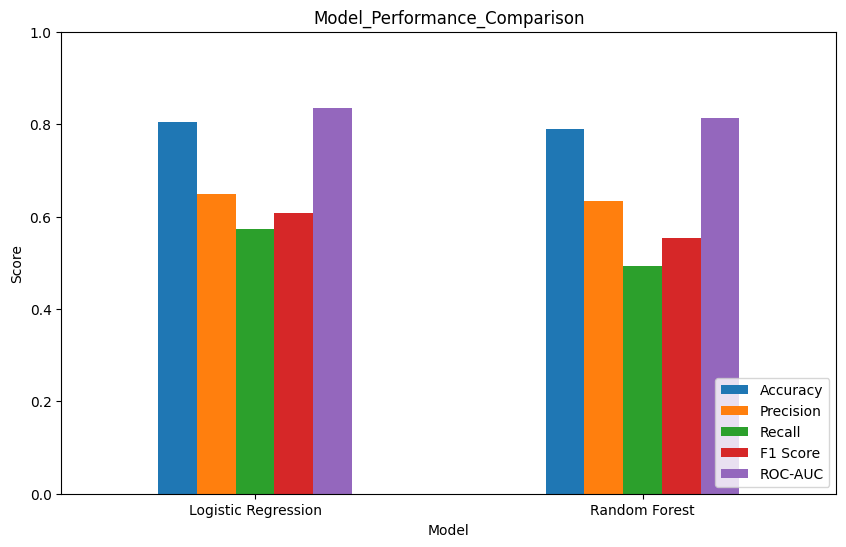

In [26]:
plt.figure(figsize=(10, 6))

results.set_index("Model").plot(kind="bar", figsize=(10, 6))

plt.title("Model_Performance_Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

Hyperparameter Tuning

In [27]:
# Hyperparameter tuning for Random Forest
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]}

grid_search = GridSearchCV(rf_model,param_grid,cv=5,scoring="f1",n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(grid_search.best_score_, 4))

Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Best Cross-Validation F1-score:
0.5873


Evaluating the Optimized Model

In [28]:
# Best tuned model
best_model = grid_search.best_estimator_

# Predictions
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Metrics
best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best)
best_recall = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)
best_auc = roc_auc_score(y_test, y_prob_best)

print("Optimized_Random_Forest_Results")
print("Accuracy :", round(best_accuracy, 4))
print("Precision:", round(best_precision, 4))
print("Recall   :", round(best_recall, 4))
print("F1 Score :", round(best_f1, 4))
print("ROC-AUC  :", round(best_auc, 4))

Optimized_Random_Forest_Results
Accuracy : 0.7925
Precision: 0.6395
Recall   : 0.5027
F1 Score : 0.5629
ROC-AUC  : 0.8329


Confusion matrix

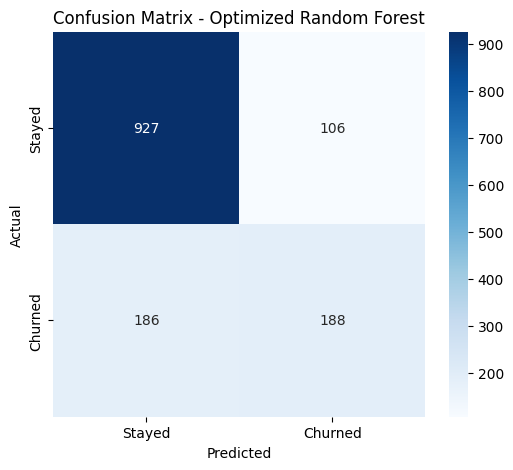

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"])

plt.title("Confusion Matrix - Optimized Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Peport

In [30]:
print("_____________Classification_Report______________")

print(classification_report(y_test,y_pred_best,target_names=["Stayed", "Churned"]))

_____________Classification_Report______________
              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.86      1033
     Churned       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



ROC curve

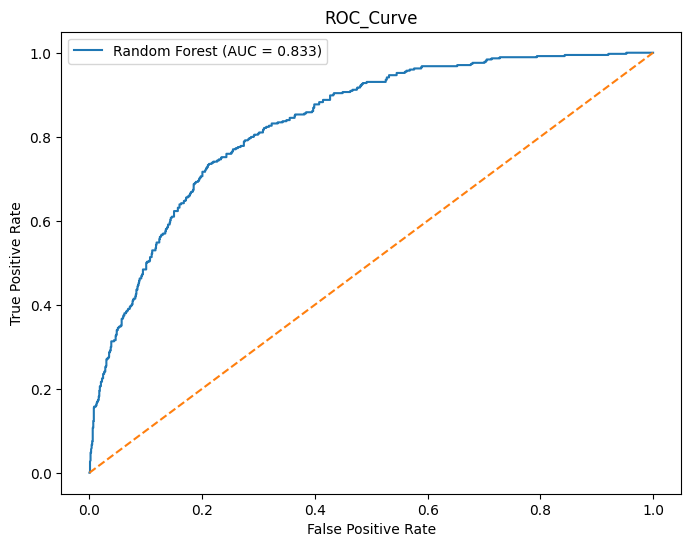

In [31]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr,label=f"Random Forest (AUC = {best_auc:.3f})")
plt.plot([0, 1],[0, 1],linestyle="--")

plt.title("ROC_Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

Feature Importance

In [32]:
# Getting transformed feature names
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Getting feature importance
importances = best_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({"Feature": feature_names,"Importance": importances})
feature_importance = feature_importance.sort_values("Importance",ascending=False)

feature_importance.head(15)

,Feature,Importance
1,num__tenure,0.143556
3,num__TotalCharges,0.130446
36,cat__Contract_Month-to-month,0.096448
2,num__MonthlyCharges,0.084524
18,cat__OnlineSecurity_No,0.051500
16,cat__InternetService_Fiber optic,0.050592
43,cat__PaymentMethod_Electronic check,0.044325
27,cat__TechSupport_No,0.036839
38,cat__Contract_Two year,0.033822
21,cat__OnlineBackup_No,0.018801


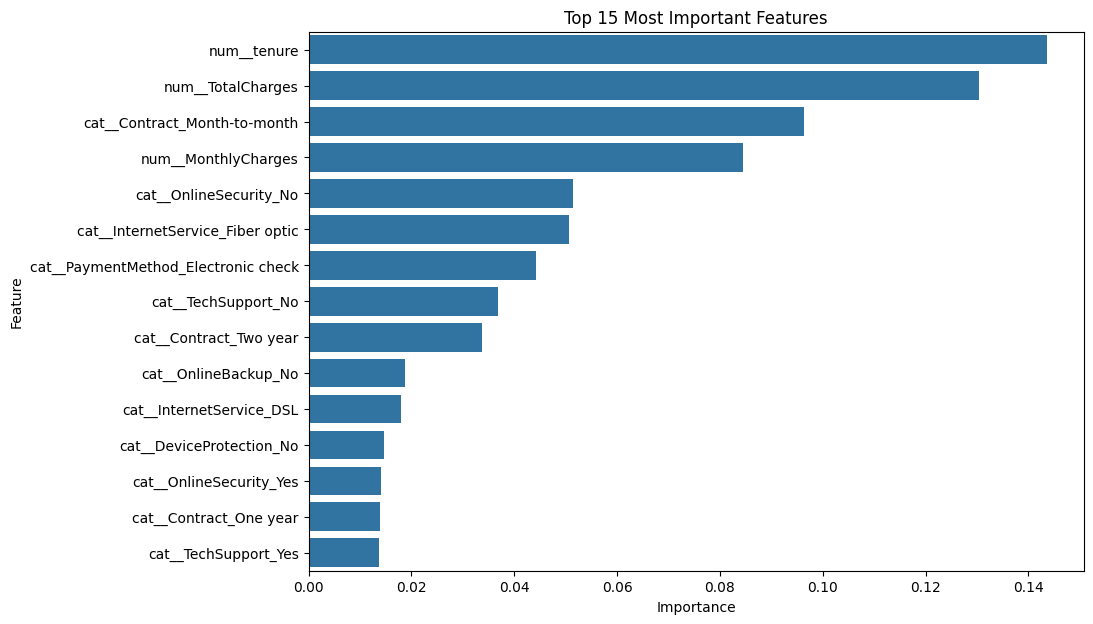

In [33]:
plt.figure(figsize=(10, 7))

sns.barplot(data=feature_importance.head(15),x="Importance",y="Feature")

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Interactive deployment

In [34]:
#creating a simple interactive form using ipywidgets
import ipywidgets as widgets
from IPython.display import display, clear_output

# Creating input widgets
tenure_widget = widgets.IntSlider(value=12,min=0,max=72,step=1,description="Tenure:")

monthly_widget = widgets.FloatText(value=70.0,description="Monthly:")

total_widget = widgets.FloatText(value=800.0,description="Total:")

contract_widget = widgets.Dropdown(options=["Month-to-month", "One year", "Two year"],value="Month-to-month",description="Contract:")

internet_widget = widgets.Dropdown(options=["DSL", "Fiber optic", "No"],value="Fiber optic",description="Internet:")

payment_widget = widgets.Dropdown(options=["Electronic check","Mailed check","Bank transfer (automatic)","Credit card (automatic)"],
    value="Electronic check",description="Payment:")

button = widgets.Button(description="Predict Churn")

output = widgets.Output()

In [35]:
def predict_churn(button_click):

    with output:
        clear_output()

        new_customer = pd.DataFrame({
            "gender": ["Male"],
            "SeniorCitizen": [0],
            "Partner": ["No"],
            "Dependents": ["No"],
            "tenure": [tenure_widget.value],
            "PhoneService": ["Yes"],
            "MultipleLines": ["No"],
            "InternetService": [internet_widget.value],
            "OnlineSecurity": ["No"],
            "OnlineBackup": ["No"],
            "DeviceProtection": ["No"],
            "TechSupport": ["No"],
            "StreamingTV": ["No"],
            "StreamingMovies": ["No"],
            "Contract": [contract_widget.value],
            "PaperlessBilling": ["Yes"],
            "PaymentMethod": [payment_widget.value],
            "MonthlyCharges": [monthly_widget.value],
            "TotalCharges": [total_widget.value]})

        prediction = best_model.predict(new_customer)[0]
        probability = best_model.predict_proba(new_customer)[0][1]

        if prediction == 1:
            print("Prediction: Customer is likely to CHURN.")
        else:
            print("Prediction: Customer is likely to STAY.")

        print(f"Estimated churn probability: {probability:.2%}")

button.on_click(predict_churn)

display(tenure_widget,monthly_widget,total_widget,
    contract_widget,internet_widget,payment_widget,button,output)

IntSlider(value=12, description='Tenure:', max=72)

FloatText(value=70.0, description='Monthly:')

FloatText(value=800.0, description='Total:')

Dropdown(description='Contract:', options=('Month-to-month', 'One year', 'Two year'), value='Month-to-month')

Dropdown(description='Internet:', index=1, options=('DSL', 'Fiber optic', 'No'), value='Fiber optic')

Dropdown(description='Payment:', options=('Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Cr…

Button(description='Predict Churn', style=ButtonStyle())

Output()

Summary of Findings

The customer churn dataset containes 7,043 customers, and after cleaning and exploring the data, 7,032 records remained. About 26.58% of customers churned, while 73.42% stayed. Logistic Regression performed better than the initial Random Forest, achieving 80.38% accuracy and 83.59% ROC-AUC. The optimized Random Forest achieved 79.25% accuracy and 83.29% ROC-AUC.

Conclusion

This assignment project showed that machine learning can be used to predict customer churn and identify unhappy customers that maybe at higher risk of leaving and staying. The data was successfully cleaned, explored, and prepared. Multiple models were trained and evaluated. Logistic Regression produced the strongest test results.Random Forest model was optimized using five-fold cross-validation and GridSearchCV. I have succeassfully created an interactive Google Colab interface also showed how the model can make predictions for new customers. In conclusion, the assignment project successfully applied the machine learning process to a real-world customer churn problem.

Colab Link

https://colab.research.google.com/drive/1y7_xL5BemJHRWJhrPdMWrG7DESsUkVEB?usp=sharing